In [14]:
import sys
from pathlib import Path
_here = Path.cwd()
sys.path.insert(0, str(_here if (_here / "project_config.py").exists() else _here / "scripts"))
from project_config import *

import numpy as np, pandas as pd
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_predict

model_df = load_model_df()
y = model_df["phq9"]
assert len(ACOUSTIC) == 72

# Subject -> type (MDD/HC) map, keyed on int to bridge the zero-padding difference
inv = pd.read_csv(DATA_DIR / "wav_inventory.csv", dtype={"subject_id": str})
type_map = (inv.drop_duplicates("subject_id")
               .assign(k=lambda d: d["subject_id"].astype(int))
               .set_index("k")["type"])
subject_types = model_df["subject_key"].astype(int).map(type_map).values

kf = KFold(n_splits=10, shuffle=True, random_state=SEED)   # main CV object for error export

def export_errors(name, feature_cols, model):
    """OOF predictions + residuals for one feature set, sorted by absolute error, saved to CSV."""
    X = model_df[feature_cols]
    pred = cross_val_predict(model, X, y, cv=kf, n_jobs=1)
    out = pd.DataFrame({
        "subject_id": model_df["subject_key"].values,
        "type":       subject_types,
        "phq9_true":  y.values,
        "phq9_pred":  np.round(pred, 2),
        "residual":   np.round(y.values - pred, 2),        # + = under-predicted (model too low)
        "abs_error":  np.round(np.abs(y.values - pred), 2),
    }).sort_values("abs_error", ascending=False).reset_index(drop=True)
    out.to_csv(DATA_DIR / f"predictions_{name}.csv", index=False)
    print(f"=== {name.upper()}: top 5 errors ===")
    print(out.head(5).to_string(index=False))
    return out

print(f"Loaded model_df {model_df.shape}; unmapped types: {pd.isna(subject_types).sum()}")


Loaded model_df (52, 98); unmapped types: 0


In [15]:
# Inspect largest prediction errors: export OOF predictions + residuals
demo_err  = export_errors("demographics", DEMO,     RandomForestRegressor(random_state=SEED))
psych_err = export_errors("psych",        PSYCH,    RandomForestRegressor(random_state=SEED))
clin_err  = export_errors("clinical",     CLINICAL, RandomForestRegressor(random_state=SEED))
ac_err    = export_errors("acoustic",     ACOUSTIC, RandomForestRegressor(random_state=SEED))


=== DEMOGRAPHICS: top 5 errors ===
subject_id type  phq9_true  phq9_pred  residual  abs_error
   2010014  MDD         20       2.78     17.22      17.22
   2010005  MDD         19       2.76     16.24      16.24
   2030014   HC          3      17.56    -14.56      14.56
   2020008   HC          1      14.52    -13.52      13.52
   2010012  MDD         22       9.77     12.23      12.23
=== PSYCH: top 5 errors ===
subject_id type  phq9_true  phq9_pred  residual  abs_error
   2010034  MDD         16       4.57     11.43      11.43
   2010037  MDD          6      16.31    -10.31      10.31
   2020021   HC          4      12.62     -8.62       8.62
   2010039  MDD         25      18.00      7.00       7.00
   2010001  MDD         21      14.41      6.59       6.59
=== CLINICAL: top 5 errors ===
subject_id type  phq9_true  phq9_pred  residual  abs_error
   2010037  MDD          6      17.59    -11.59      11.59
   2010034  MDD         16       4.97     11.03      11.03
   2020021   HC      

In [12]:
# Review mispredicted subjects across models
import numpy as np, pandas as pd
from pathlib import Path

DATA_DIR = Path.cwd()
if not (DATA_DIR / "predictions_psych.csv").exists():
    DATA_DIR = DATA_DIR.parent

model_names = ["demographics", "psych", "clinical", "acoustic"]
errs = {m: pd.read_csv(DATA_DIR / f"predictions_{m}.csv", dtype={"subject_id": str})
        for m in model_names}

# residual = true - pred:  > 0 = UNDER-predicted (model too low), < 0 = OVER-predicted
# --- 1 & 2: top over/under per model ---
for m, df in errs.items():
    print(f"\n=== {m.upper()} ===")
    print("Top 5 UNDER-predicted (model too LOW, missed high scorers):")
    print(df.nlargest(5, "residual")[["subject_id","type","phq9_true","phq9_pred","residual"]].to_string(index=False))
    print("Top 5 OVER-predicted (model too HIGH, inflated low scorers):")
    print(df.nsmallest(5, "residual")[["subject_id","type","phq9_true","phq9_pred","residual"]].to_string(index=False))

# --- 3: hard for multiple models ---
wide = None
for m, df in errs.items():
    s = df.set_index("subject_id")["abs_error"].rename(m)
    wide = s.to_frame() if wide is None else wide.join(s)
wide["mean_abs_error"] = wide[model_names].mean(axis=1)

# how many models rank this subject in their top-5 worst errors
hard = pd.Series(0, index=wide.index)
for m, df in errs.items():
    hard.loc[df.nlargest(5, "abs_error")["subject_id"]] += 1
wide["in_top5_of_n_models"] = hard

print("\n=== Subjects hardest across models (by mean abs error) ===")
print(wide.sort_values("mean_abs_error", ascending=False).head(10).round(2).to_string())

# --- 4: data-quality cross-reference ---
# recordings per subject (per-recording feature file), keyed on int to match id formats
feat = pd.read_csv(DATA_DIR / "egemaps_features.csv", dtype={"subject_id": str})
rec_counts = feat.groupby(feat["subject_id"].astype(int)).size().rename("n_recordings")

dq = errs["psych"][["subject_id", "type", "phq9_true"]].copy()
dq["k"] = dq["subject_id"].astype(int)
dq["n_recordings"] = dq["k"].map(rec_counts)
dq["mean_abs_error"] = dq["subject_id"].map(wide["mean_abs_error"])
dq["flag"] = ""
dq.loc[dq["n_recordings"] < 29, "flag"] += "few_recordings "     # lost clips (cleaning/corrupt)
dq.loc[dq["phq9_true"] >= 20,   "flag"] += "very_high_phq9 "     # severe end
dq.loc[dq["phq9_true"] == 0,    "flag"] += "floor_phq9 "         # exact zero

print("\n=== Data-quality flags on the hardest subjects ===")
print(dq.sort_values("mean_abs_error", ascending=False)
        .head(12)[["subject_id","type","phq9_true","n_recordings","mean_abs_error","flag"]]
        .to_string(index=False))



=== DEMOGRAPHICS ===
Top 5 UNDER-predicted (model too LOW, missed high scorers):
subject_id type  phq9_true  phq9_pred  residual
   2010014  MDD         20       2.78     17.22
   2010005  MDD         19       2.76     16.24
   2010012  MDD         22       9.77     12.23
   2010039  MDD         25      13.99     11.01
   2010006  MDD         16       5.08     10.92
Top 5 OVER-predicted (model too HIGH, inflated low scorers):
subject_id type  phq9_true  phq9_pred  residual
   2030014   HC          3      17.56    -14.56
   2020008   HC          1      14.52    -13.52
   2030010   HC          2      14.21    -12.21
   2030017   HC          3      14.74    -11.74
   2020014   HC          3      13.64    -10.64

=== PSYCH ===
Top 5 UNDER-predicted (model too LOW, missed high scorers):
subject_id type  phq9_true  phq9_pred  residual
   2010034  MDD         16       4.57     11.43
   2010039  MDD         25      18.00      7.00
   2010001  MDD         21      14.41      6.59
   2010011  MD

In [16]:
# Search for error patterns for all four models
import numpy as np, pandas as pd
from pathlib import Path

DATA_DIR = Path.cwd()
if not (DATA_DIR / "predictions_psych.csv").exists():
    DATA_DIR = DATA_DIR.parent
model_df = pd.read_csv(DATA_DIR / "model_df.csv", dtype={"subject_key": str})

MODELS = ["demographics", "psych", "clinical", "acoustic"]
clinical_scales = PSYCH

base = model_df.copy()
base["k"] = base["subject_key"].astype(int)
for m in MODELS:
    d = pd.read_csv(DATA_DIR / f"predictions_{m}.csv", dtype={"subject_id": str})
    d["k"] = d["subject_id"].astype(int)
    base = base.merge(d[["k", "abs_error", "residual"]]
                      .rename(columns={"abs_error": f"abs_{m}", "residual": f"res_{m}"}), on="k")

# --- 1. Errors vs PHQ-9 severity ---
print("=== 1. Error vs PHQ-9 severity ===")
print(f"{'model':13s}{'corr(PHQ9,|err|)':>18}{'corr(PHQ9,resid)':>18}")
for m in MODELS:
    print(f"{m:13s}{base['phq9'].corr(base[f'abs_{m}']):>18.3f}{base['phq9'].corr(base[f'res_{m}']):>18.3f}")

# --- 2. Errors by gender / age ---
print("\n=== 2. Error by gender (0=F, 1=M) and age ===")
print(f"{'model':13s}{'|err| F':>10}{'|err| M':>10}{'corr(age,|err|)':>18}")
for m in MODELS:
    g = base.groupby("gender")[f"abs_{m}"].mean()
    print(f"{m:13s}{g.get(0, np.nan):>10.2f}{g.get(1, np.nan):>10.2f}"
          f"{base['age'].corr(base[f'abs_{m}']):>18.3f}")

# --- 3. Errors vs questionnaires ---
print("\n=== 3. corr(|error|, clinical scale) ===")
corr_tbl = pd.DataFrame({m: [base[f"abs_{m}"].corr(base[s]) for s in clinical_scales]
                         for m in MODELS}, index=clinical_scales).round(3)
print(corr_tbl.to_string())

# acoustic-feature distributions vs each model's error
acoustic_cols = ACOUSTIC
print("\nTop 3 acoustic features correlated with each model's |error|:")
for m in MODELS:
    top = base[acoustic_cols].corrwith(base[f"abs_{m}"]).abs().sort_values(ascending=False).head(3)
    print(f"  {m:13s}: " + ", ".join(f"{f} ({v:.2f})" for f, v in top.items()))

# --- 4. Do the models fail on the SAME subjects? (pairwise |error| correlations) ---
print("\n=== 4. Pairwise |error| correlation across models ===")
abs_cols = [f"abs_{m}" for m in MODELS]
fail_corr = base[abs_cols].corr().round(2)
fail_corr.index = MODELS; fail_corr.columns = MODELS
print(fail_corr.to_string())
print("(low off-diagonal = models fail on DIFFERENT subjects = complementary)")

# Subject-level: mean error across models + how many models find each subject hard
wide = base.set_index("subject_key")[abs_cols].copy()
wide.columns = MODELS
wide["mean_abs"] = wide.mean(axis=1)
hard = pd.Series(0, index=wide.index)
for m in MODELS:
    hard.loc[wide[m].nlargest(5).index] += 1
wide["in_top5_of_n"] = hard
print("\nHardest subjects overall:")
print(wide.sort_values("mean_abs", ascending=False).head(8).round(2).to_string())

=== 1. Error vs PHQ-9 severity ===
model          corr(PHQ9,|err|)  corr(PHQ9,resid)
demographics              0.202             0.726
psych                     0.439             0.366
clinical                  0.478             0.387
acoustic                  0.351             0.892

=== 2. Error by gender (0=F, 1=M) and age ===
model           |err| F   |err| M   corr(age,|err|)
demographics       7.00      5.40            -0.185
psych              2.15      2.69            -0.134
clinical           2.41      2.74            -0.134
acoustic           5.59      6.41             0.080

=== 3. corr(|error|, clinical scale) ===
        demographics  psych  clinical  acoustic
ctq_sf         0.118  0.184     0.182     0.174
LES           -0.246 -0.127    -0.095    -0.208
SSRS          -0.022 -0.612    -0.576    -0.263
gad7           0.164  0.351     0.398     0.383
PSQI           0.140  0.321     0.337     0.236

Top 3 acoustic features correlated with each model's |error|:
  demographics 

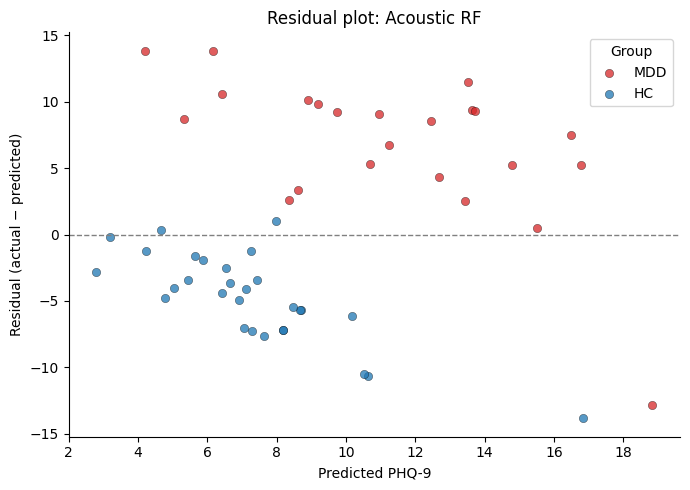

In [ ]:
# Residual plot (predicted vs residual) to check for heteroscedasticity
import pandas as pd, matplotlib.pyplot as plt

df = pd.read_csv(DATA_DIR / "predictions_acoustic.csv", dtype={"subject_id": str}) 

fig, ax = plt.subplots(figsize=(7, 5))
for grp, color in [("MDD", "#d62728"), ("HC", "#1f77b4")]:
    sub = df[df["type"] == grp]
    ax.scatter(sub["phq9_pred"], sub["residual"], label=grp, color=color,
               alpha=0.75, edgecolor="k", linewidth=0.3)

ax.axhline(0, color="gray", ls="--", lw=1)                 # zero-residual reference
ax.set_xlabel("Predicted PHQ-9")
ax.set_ylabel("Residual (actual − predicted)")
ax.set_title("Residual plot: Acoustic RF")
ax.legend(title="Group")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


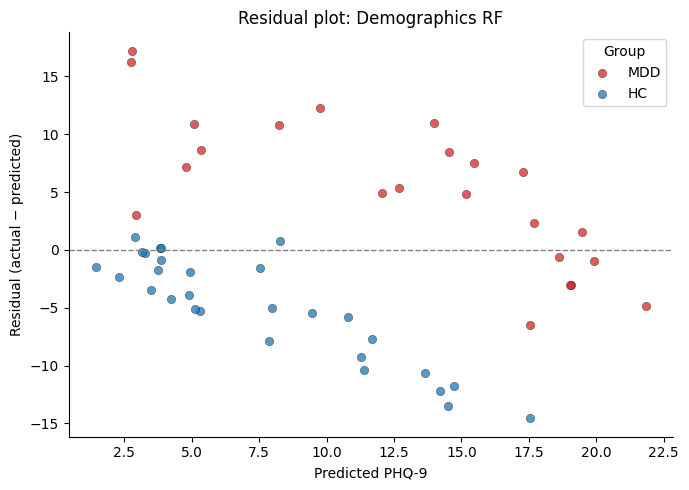

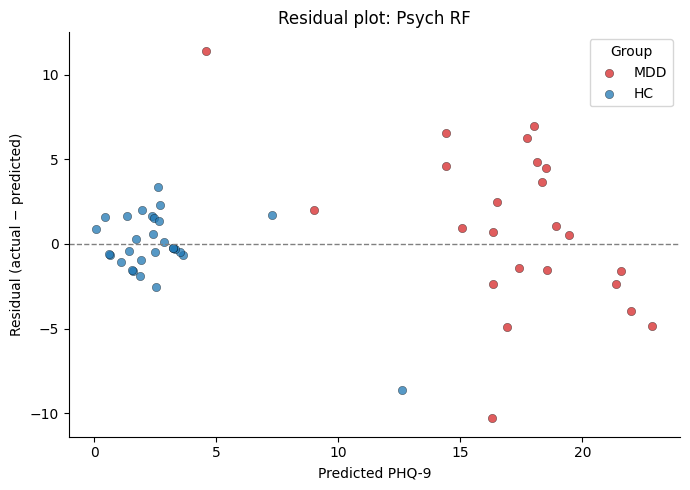

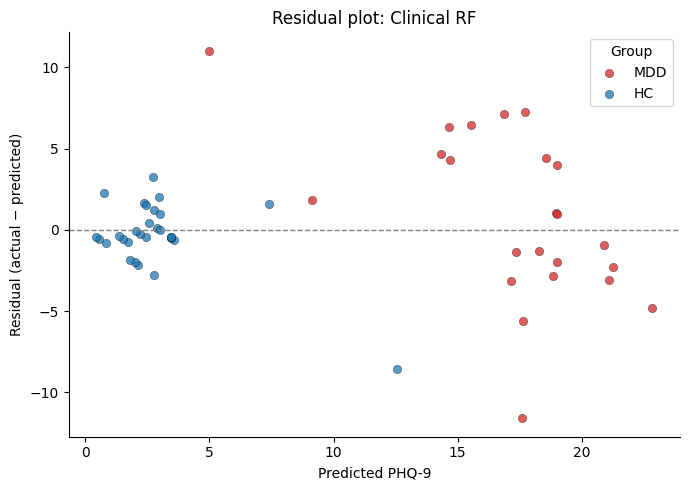

In [20]:
import pandas as pd, matplotlib.pyplot as plt

def residual_plot(name, title):
    df = pd.read_csv(DATA_DIR / f"predictions_{name}.csv", dtype={"subject_id": str})
    fig, ax = plt.subplots(figsize=(7, 5))
    for grp, color in [("MDD", "#d62728"), ("HC", "#1f77b4")]:
        sub = df[df["type"] == grp]
        ax.scatter(sub["phq9_pred"], sub["residual"], label=grp, color=color,
                   alpha=0.75, edgecolor="k", linewidth=0.3)
    ax.axhline(0, color="gray", ls="--", lw=1)
    ax.set_xlabel("Predicted PHQ-9")
    ax.set_ylabel("Residual (actual − predicted)")
    ax.set_title(title)
    ax.legend(title="Group")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

residual_plot("demographics", "Residual plot: Demographics RF")
residual_plot("psych",        "Residual plot: Psych RF")
residual_plot("clinical",     "Residual plot: Clinical RF")
